In [1]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
play_store_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\Play Store Data.csv")

In [4]:
play_store_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
reviews_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\User Reviews.csv")
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [6]:
reviews_df.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='str')

In [7]:
play_store_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [8]:
play_store_df["Size"].head()

0     19M
1     14M
2    8.7M
3     25M
4    2.8M
Name: Size, dtype: str

In [9]:
play_store_df["Installs"].head()

0        10,000+
1       500,000+
2     5,000,000+
3    50,000,000+
4       100,000+
Name: Installs, dtype: str

In [10]:
play_store_df.shape

(10841, 13)

In [11]:
reviews_df.shape

(64295, 5)

In [12]:
play_store_df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [13]:
reviews_df.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [14]:
def convert_size(size):

    if isinstance(size, str):

        if 'M' in size:
            return float(size.replace('M', ''))

        elif 'k' in size:
            return float(size.replace('k', '')) / 1024

    return np.nan


play_store_df["Size_MB"] = play_store_df["Size"].apply(convert_size)

In [15]:
play_store_df[["Size", "Size_MB"]].head()

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8


In [16]:
play_store_df = play_store_df.dropna(subset=["Size_MB"])

In [17]:
play_store_df["Size_MB"].isnull().sum()

np.int64(0)

In [18]:
play_store_df = play_store_df[play_store_df["Installs"] != "Free"]
play_store_df["Installs_Num"] = (

    play_store_df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)

)

In [19]:
play_store_df[["Installs", "Installs_Num"]].head()

,Installs,Installs_Num
0,"10,000+",10000.0
1,"500,000+",500000.0
2,"5,000,000+",5000000.0
3,"50,000,000+",50000000.0
4,"100,000+",100000.0


In [20]:
play_store_df = play_store_df.dropna(subset=["Installs_Num"])

In [21]:
play_store_df["Installs_Num"].isnull().sum()

np.int64(0)

In [22]:
play_store_df.info()

<class 'pandas.DataFrame'>
Index: 9145 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9145 non-null   str    
 1   Category        9145 non-null   str    
 2   Rating          7729 non-null   float64
 3   Reviews         9145 non-null   str    
 4   Size            9145 non-null   str    
 5   Installs        9145 non-null   str    
 6   Type            9145 non-null   str    
 7   Price           9145 non-null   str    
 8   Content Rating  9145 non-null   str    
 9   Genres          9145 non-null   str    
 10  Last Updated    9145 non-null   str    
 11  Current Ver     9137 non-null   str    
 12  Android Ver     9143 non-null   str    
 13  Size_MB         9145 non-null   float64
 14  Installs_Num    9145 non-null   float64
dtypes: float64(3), str(12)
memory usage: 2.0 MB


In [23]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 8.3 MB


In [24]:
play_store_df.shape

(9145, 15)

In [25]:
reviews_df.shape

(64295, 5)

In [26]:
play_store_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Installs_Num
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0,10000.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,500000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7,5000000.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0,50000000.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8,100000.0


In [27]:
print("App" in play_store_df.columns)
print("App" in reviews_df.columns)

True
True


In [28]:
merged_df = pd.merge(play_store_df, reviews_df, on='App', how='inner')

In [29]:
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Installs_Num,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,500000.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,500000.0,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,500000.0,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,500000.0,NaN,NaN,NaN,NaN
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,500000.0,I love colors inspyering,Positive,0.500,0.600000


In [30]:
merged_df.shape

(75432, 19)

In [31]:
merged_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_MB', 'Installs_Num', 'Translated_Review',
       'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity'],
      dtype='str')

In [32]:
selected_categories = [

'GAME',
'BEAUTY',
'BUSINESS',
'COMICS',
'COMMUNICATION',
'DATING',
'ENTERTAINMENT',
'SOCIAL',
'EVENTS'

]

In [33]:
merged_df["Reviews"].dtype

<StringDtype(na_value=nan)>

In [34]:
merged_df["Reviews"] = pd.to_numeric(
    merged_df["Reviews"],
    errors="coerce"
)

In [35]:
merged_df = merged_df.dropna(subset=["Reviews"])

In [36]:
merged_df["Reviews"].dtype

dtype('int64')

In [37]:
merged_df["Reviews"] > 500

0         True
1         True
2         True
3         True
4         True
         ...  
75427    False
75428    False
75429    False
75430    False
75431    False
Name: Reviews, Length: 75432, dtype: bool

In [38]:
merged_df["Sentiment_Subjectivity"].dtype

dtype('float64')

In [39]:
merged_df["Sentiment_Subjectivity"] = pd.to_numeric(
    merged_df["Sentiment_Subjectivity"],
    errors="coerce"
)

In [40]:
merged_df = merged_df.dropna(
    subset=["Sentiment_Subjectivity"]
)

In [41]:
merged_df["Rating"].dtype
merged_df["Rating"] = pd.to_numeric(
    merged_df["Rating"],
    errors="coerce"
)
merged_df = merged_df.dropna(
    subset=["Rating"]
)

In [42]:
filtered_df = merged_df[

    (merged_df["Rating"] > 3.5)

    &

    (merged_df["Reviews"] > 500)

    &

    (merged_df["Installs_Num"] > 50000)

    &

    (merged_df["Sentiment_Subjectivity"] > 0.5)

    &

    (~merged_df["App"].str.contains(
        "s",
        case=False,
        na=False
    ))

    &

    (merged_df["Category"].isin(
        selected_categories
    ))

]

In [43]:
filtered_df.shape
filtered_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Installs_Num,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
2028,Google Primer,BUSINESS,4.4,62272,18M,"10,000,000+",Free,0,Everyone,Business,"June 26, 2018",3.550.2,4.1 and up,18.0,10000000.0,Great,Positive,0.800000,0.750000
2030,Google Primer,BUSINESS,4.4,62272,18M,"10,000,000+",Free,0,Everyone,Business,"June 26, 2018",3.550.2,4.1 and up,18.0,10000000.0,Good,Positive,0.700000,0.600000
2035,Call Blocker,BUSINESS,4.6,188841,3.2M,"5,000,000+",Free,0,Everyone,Business,"June 21, 2018",1.1.13,4.0 and up,3.2,5000000.0,"So far able block annoying machines, recording...",Negative,-0.050000,0.881250
2082,Call Blocker,BUSINESS,4.6,188841,3.2M,"5,000,000+",Free,0,Everyone,Business,"June 21, 2018",1.1.13,4.0 and up,3.2,5000000.0,Finally call blocker works. Also option block ...,Positive,0.177857,0.559286
2104,Call Blocker,BUSINESS,4.6,188841,3.2M,"5,000,000+",Free,0,Everyone,Business,"June 21, 2018",1.1.13,4.0 and up,3.2,5000000.0,New pop ad free version pops several times tim...,Negative,-0.043939,0.525758


In [44]:
translations = {

    "BEAUTY": "सौंदर्य",
    "BUSINESS": "வணிகம்",
    "DATING": "Partnersuche"

}

In [45]:
filtered_df["Display_Category"] = filtered_df["Category"].replace(translations)

In [46]:
filtered_df[["Category", "Display_Category"]].head(25)

,Category,Display_Category
2028,BUSINESS,வணிகம்
2030,BUSINESS,வணிகம்
2035,BUSINESS,வணிகம்
2082,BUSINESS,வணிகம்
2104,BUSINESS,வணிகம்
4715,COMMUNICATION,COMMUNICATION
4762,COMMUNICATION,COMMUNICATION
4784,COMMUNICATION,COMMUNICATION
4794,COMMUNICATION,COMMUNICATION
4843,COMMUNICATION,COMMUNICATION


In [47]:
filtered_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_MB', 'Installs_Num', 'Translated_Review',
       'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity',
       'Display_Category'],
      dtype='str')

In [48]:
filtered_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Installs_Num,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Display_Category
2028,Google Primer,BUSINESS,4.4,62272,18M,"10,000,000+",Free,0,Everyone,Business,"June 26, 2018",3.550.2,4.1 and up,18.0,10000000.0,Great,Positive,0.800000,0.750000,வணிகம்
2030,Google Primer,BUSINESS,4.4,62272,18M,"10,000,000+",Free,0,Everyone,Business,"June 26, 2018",3.550.2,4.1 and up,18.0,10000000.0,Good,Positive,0.700000,0.600000,வணிகம்
2035,Call Blocker,BUSINESS,4.6,188841,3.2M,"5,000,000+",Free,0,Everyone,Business,"June 21, 2018",1.1.13,4.0 and up,3.2,5000000.0,"So far able block annoying machines, recording...",Negative,-0.050000,0.881250,வணிகம்
2082,Call Blocker,BUSINESS,4.6,188841,3.2M,"5,000,000+",Free,0,Everyone,Business,"June 21, 2018",1.1.13,4.0 and up,3.2,5000000.0,Finally call blocker works. Also option block ...,Positive,0.177857,0.559286,வணிகம்
2104,Call Blocker,BUSINESS,4.6,188841,3.2M,"5,000,000+",Free,0,Everyone,Business,"June 21, 2018",1.1.13,4.0 and up,3.2,5000000.0,New pop ad free version pops several times tim...,Negative,-0.043939,0.525758,வணிகம்


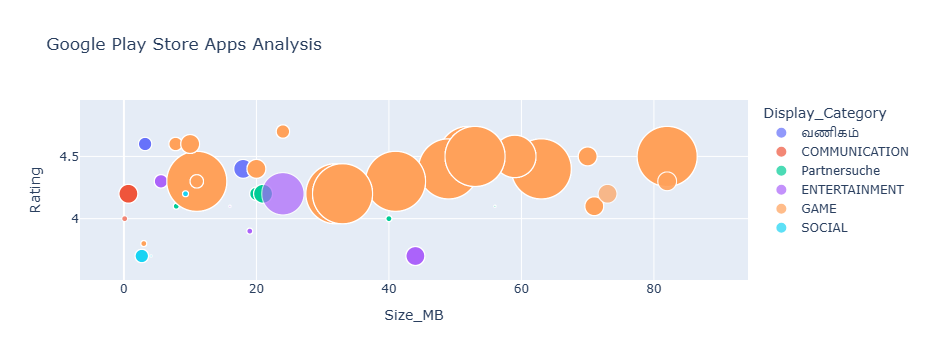

In [49]:
import plotly.express as px

fig = px.scatter(

    filtered_df,

    x="Size_MB",

    y="Rating",

    size="Installs_Num",

    color="Display_Category",

    hover_name="App",

    size_max=60,

    title="Google Play Store Apps Analysis"

)

fig.show()

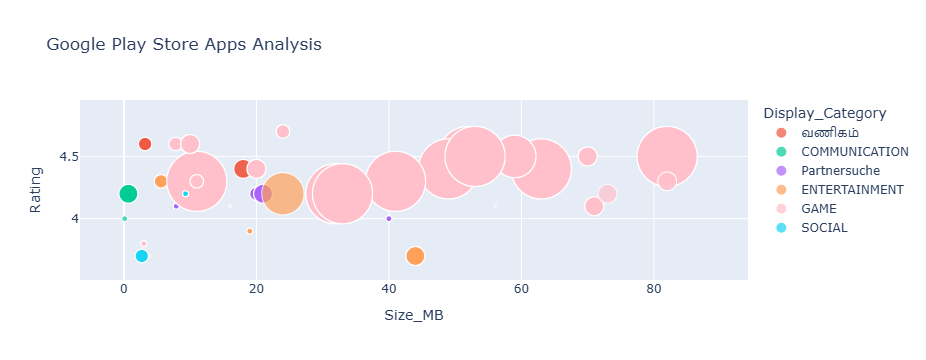

In [50]:
import plotly.express as px

fig = px.scatter(

    filtered_df,

    x="Size_MB",
    y="Rating",
    size="Installs_Num",
    color="Display_Category",
    hover_name="App",
    size_max=60,
    title="Google Play Store Apps Analysis",

    color_discrete_map={

        "GAME": "pink"

    }

)

fig.show()

In [51]:
from datetime import datetime

In [52]:
current_hour = datetime.now().hour
print(current_hour)

18


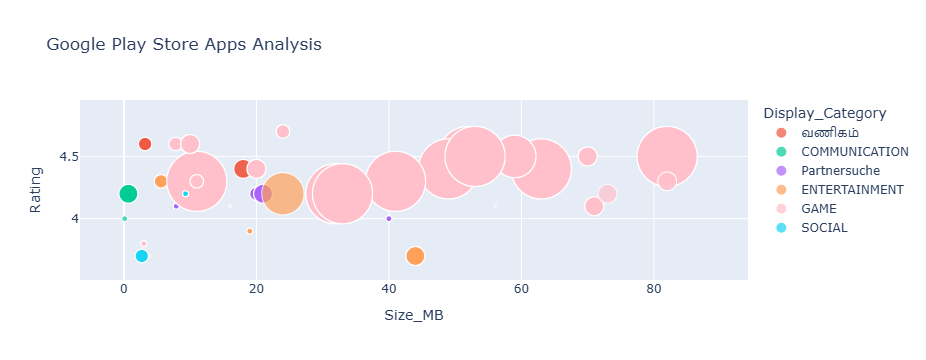

In [53]:
if 17 <= current_hour < 19:
    fig.show()
else:
    print("Bubble Chart is available only between 5 PM IST and 7 PM IST.")

In [54]:
from datetime import datetime
import pytz

ist = pytz.timezone("Asia/Kolkata")

current_hour = datetime.now(ist).hour

print(current_hour)

18


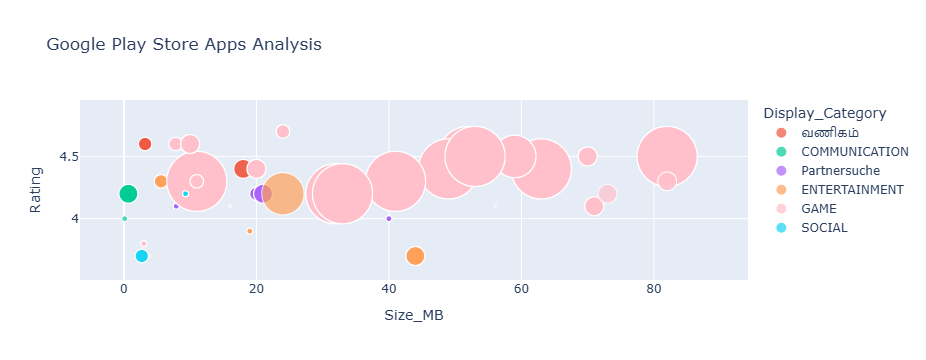

In [55]:
if 17 <= current_hour < 19:
    fig.show()
else:
    print("Bubble Chart is available only between 5 PM IST and 7 PM IST.")

In [56]:
print(current_hour)

18


In [57]:
current_hour = 17

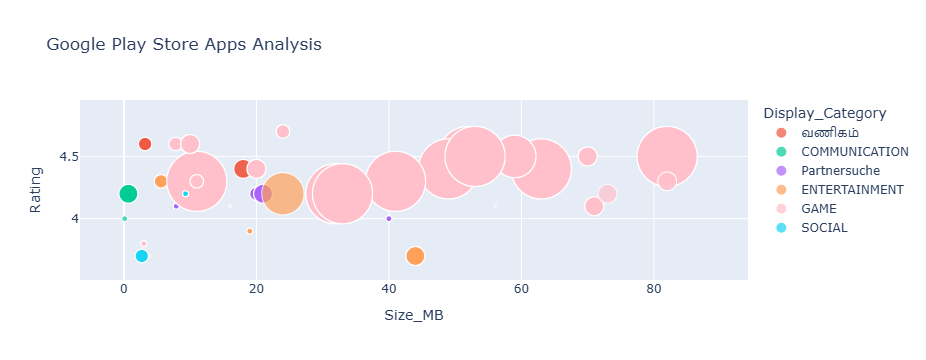

In [58]:
if 17 <= current_hour < 19:
    fig.show()
else:
    print("Bubble Chart is available only between 5 PM IST and 7 PM IST.")

In [59]:
current_hour = 18

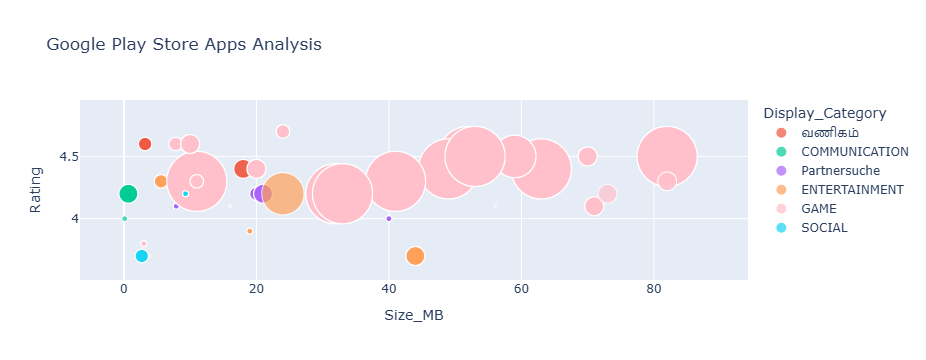

In [60]:
if 17 <= current_hour < 19:
    fig.show()
else:
    print("Bubble Chart is available only between 5 PM IST and 7 PM IST.")

In [61]:
current_hour = 16

In [62]:
if 17 <= current_hour < 19:
    fig.show()
else:
    print("Bubble Chart is available only between 5 PM IST and 7 PM IST.")

Bubble Chart is available only between 5 PM IST and 7 PM IST.


In [65]:
import pandas as pd
import numpy as np
import plotly.express as px
from datetime import datetime, timedelta, timezone
import webbrowser

try:
    play_store_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\Play Store Data.csv")
except FileNotFoundError:
    try:
        play_store_df = pd.read_csv("play_store_data.csv")
    except FileNotFoundError:
        print("❌ Error: Could not find the Play Store Data CSV file!")
        raise

try:
    reviews_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\User Reviews.csv")
except FileNotFoundError:
    try:
        reviews_df = pd.read_csv("Reviews.csv")
    except FileNotFoundError:
        print("❌ Error: Could not find the reviews CSV file!")
        raise

play_store_df = play_store_df.dropna(subset=["Rating"])
play_store_df = play_store_df[play_store_df["Rating"] <= 5]

play_store_df["Installs_Num"] = play_store_df["Installs"].astype(str).str.replace(",", "", regex=False)
play_store_df["Installs_Num"] = play_store_df["Installs_Num"].str.replace("+", "", regex=False)
play_store_df["Installs_Num"] = pd.to_numeric(play_store_df["Installs_Num"], errors="coerce").fillna(0).astype(int)

play_store_df["Reviews_Num"] = pd.to_numeric(play_store_df["Reviews"], errors="coerce").fillna(0).astype(int)

def convert_to_mb(size_val):
    size_str = str(size_val).strip()
    if 'M' in size_str:
        return float(size_str.replace('M', ''))
    elif 'k' in size_str:
        return float(size_str.replace('k', '')) / 1024
    return np.nan

play_store_df["Size_MB"] = play_store_df["Size"].apply(convert_to_mb)
play_store_df["Size_MB"] = play_store_df["Size_MB"].fillna(play_store_df["Size_MB"].median())

reviews_df = reviews_df.dropna(subset=["Translated_Review"])
merged_df = pd.merge(play_store_df, reviews_df, on="App", how="inner")

allowed_categories = ["GAME", "BEAUTY", "BUSINESS", "COMICS", "COMMUNICATION", "DATING", "ENTERTAINMENT", "SOCIAL", "EVENTS"]
filtered_df = merged_df[merged_df["Category"].str.upper().isin(allowed_categories)]

filtered_df = filtered_df[
    (filtered_df["Rating"] > 3.5) &
    (filtered_df["Reviews_Num"] > 500) &
    (filtered_df["Installs_Num"] > 50000) &
    (filtered_df["Sentiment_Subjectivity"] > 0.5)
]

filtered_df = filtered_df[~filtered_df["App"].str.contains("S", case=False, na=False)]

category_translations = {
    "BEAUTY": "सौंदर्य",
    "BUSINESS": "வணிகம்",
    "DATING": "Partnersuche"
}

def style_and_translate_categories(cat_name):
    cat_upper = str(cat_name).upper()
    if cat_upper in category_translations:
        return category_translations[cat_upper]
    return cat_upper.title()

filtered_df["Category"] = filtered_df["Category"].apply(style_and_translate_categories)

current_time_ist = datetime.now(timezone.utc) + timedelta(hours=5, minutes=30)
is_accessible = 17 <= current_time_ist.hour < 19

testing_mode = True  

if is_accessible or testing_mode:
    fig = px.scatter(
        filtered_df,
        x="Size_MB",
        y="Rating",
        size="Installs_Num",
        color="Category",
        color_discrete_map={"Game": "pink"},
        hover_name="App",
        labels={"Size_MB": "App Size (MB)", "Rating": "Average Rating"},
        title="App Size vs Rating Analysis"
    )
    
    fig.write_html("bubble_chart.html", include_plotlyjs="cdn")
    
    plots_content = """
    <div class="plot-container" onclick="openPlot('bubble_chart.html')">
        <div class="insights">💡 Click to open full-screen chart</div>
        <iframe src="bubble_chart.html"></iframe>
    </div>
    """
else:
    plots_content = f"""
    <div style="text-align: center; padding: 100px 50px; background: #222; border-radius: 10px; width: 100%; border: 2px solid #ff4d4d; box-shadow: 0 4px 15px rgba(255, 77, 77, 0.2);">
        <h2 style="color: #ff4d4d; margin-bottom: 10px; font-size: 28px;">🔒 [ACCESS DENIED] Visualization Locked</h2>
        <p style="font-size: 16px; margin-bottom: 20px;">Current IST System Time: <strong style="color: #00ffcc;">{current_time_ist.strftime('%I:%M %p')}</strong></p>
        <p style="color: #aaa; max-width: 600px; margin: 0 auto; line-height: 1.6;">This analytics visual is configured to display data strictly between 5:00 PM IST and 7:00 PM IST.</p>
    </div>
    """

dashboard_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Google Play Store Review Analytics</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            background-color: #222;
            color: #fff;
            margin: 0;
            padding: 0;
        }}
        .header {{
            display: flex;
            align-items: center;
            justify-content: center;
            padding: 20px;
            background-color: #333;
            border-bottom: 2px solid #444;
        }}
        .header img {{
            margin: 0 15px;
            height: 45px;
        }}
        .header h1 {{
            font-size: 22px;
            margin: 0;
            font-weight: 600;
        }}
        .container {{
            display: flex;
            flex-wrap: wrap;
            justify-content: center;
            padding: 40px 20px;
        }}
        .plot-container {{
            border: 2px solid #444;
            background-color: #1a1a1a;
            padding: 10px;
            width: 800px;
            height: 550px;
            overflow: hidden;
            position: relative;
            cursor: pointer;
            border-radius: 12px;
            box-shadow: 0 8px 24px rgba(0,0,0,0.3);
            transition: transform 0.2s, border-color 0.2s;
        }}
        .plot-container:hover {{
            transform: translateY(-5px);
            border-color: #ff69b4;
        }}
        .insights {{
            display: none;
            position: absolute;
            right: 15px;
            top: 15px;
            background-color: rgba(0,0,0,0.85);
            padding: 6px 12px;
            border-radius: 5px;
            color: #fff;
            font-size: 11px;
            letter-spacing: 0.5px;
            z-index: 10;
        }}
        .plot-container:hover .insights {{
            display: block;
        }}
        iframe {{
            width: 100%;
            height: 100%;
            border: none;
        }}
    </style>
    <script>
        function openPlot(filename) {{
            window.open(filename, '_blank');
        }}
    </script>
</head>
<body>
    <div class="header">
        <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4a/Logo_2013_Google.png/800px-Logo_2013_Google.png" alt="Google Logo">
        <h1>Google Play Store Review Analytics</h1>
        <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Google_Play_Store_badge_EN.svg/1024px-Google_Play_Store_badge_EN.svg.png" alt="Google Play Store Logo">
    </div>
    <div class="container">
        {plots_content}
    </div>
</body>
</html>
"""

with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(dashboard_html)

webbrowser.open("dashboard.html")

True